In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load Dataset
df = pd.read_csv(r'C:\Users\Mukesh2004\Desktop\Employee Attrition Risk Analysis and Prediction System\Dataset\data.csv')
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical features
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [ ]:

# Add Additional Features

# 1. Tenure (same as YearsAtCompany here)
df['Tenure'] = df['YearsAtCompany']

# 2. Salary vs Market Salary (median income per JobRole)
market_salary = df.groupby('JobRole')['MonthlyIncome'].median().to_dict()
df['MarketSalary'] = df['JobRole'].map(market_salary)
df['Salary_vs_Market'] = df['MonthlyIncome'] - df['MarketSalary']

# 3. Promotion Frequency (Years at Company / Years Since Last Promotion)
df['Promotion_Frequency'] = df['YearsAtCompany'] / (df['YearsSinceLastPromotion'] + 1)

In [ ]:
# Dataset Insights
total_employees = len(df)
total_attrition = df['Attrition'].sum()
attrition_rate = (total_attrition / total_employees) * 100

print(f"\n Total Employees: {total_employees}")
print(f" Employees Who Left: {total_attrition}")
print(f" Attrition Rate: {attrition_rate:.2f}%")

correlation_with_attrition = df.corr()['Attrition'].sort_values(ascending=False)[1:11]
print("\n Top Correlated Features (Potential Reasons for Leaving):")
print(correlation_with_attrition)

df['Department'] = df['Department'].map(lambda x: le_dict['Department'].inverse_transform([x])[0])
dept_attrition = df[df['Attrition'] == 1]['Department'].value_counts()
print("\n Attrition by Department:")
print(dept_attrition)

df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60], labels=['18-25', '26-35', '36-45', '46-60'])
age_attrition = df.groupby('Age_Group', observed=False)['Attrition'].mean() * 100
print("\n Attrition Rate by Age Group:")
print(age_attrition)


 Total Employees: 1470
 Employees Who Left: 237
 Attrition Rate: 16.12%

 Top Correlated Features (Potential Reasons for Leaving):
OverTime              0.246118
MaritalStatus         0.162070
DistanceFromHome      0.077924
JobRole               0.067151
Department            0.063991
NumCompaniesWorked    0.043494
Gender                0.029453
EducationField        0.026846
MonthlyRate           0.015170
PerformanceRating     0.002889
Name: Attrition, dtype: float64

 Attrition by Department:
Department
Research & Development    133
Sales                      92
Human Resources            12
Name: count, dtype: int64

 Attrition Rate by Age Group:
Age_Group
18-25    34.782609
26-35    19.141914
36-45     9.188034
46-60    12.454212
Name: Attrition, dtype: float64


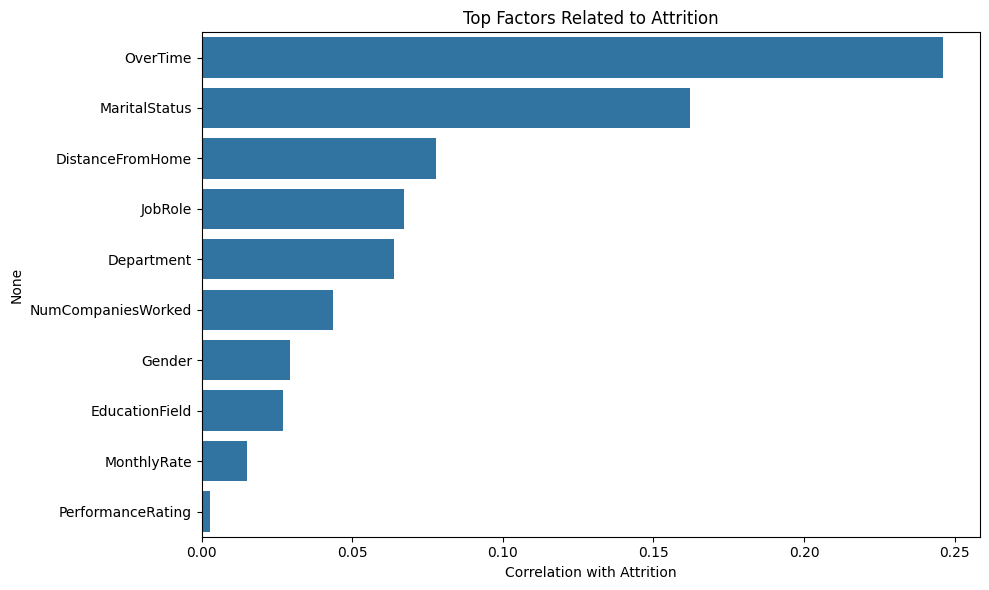

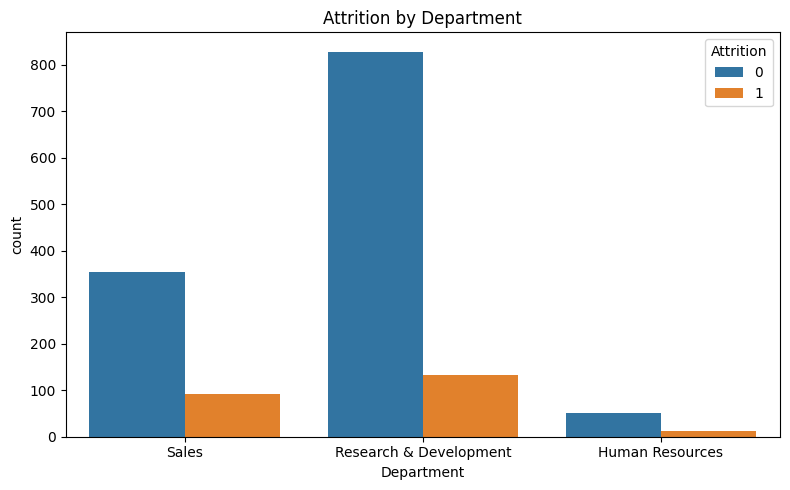

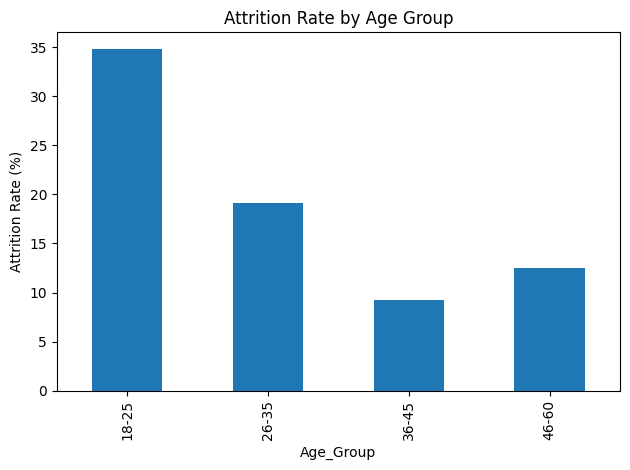

In [ ]:
# Visualizations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_attrition.values, y=correlation_with_attrition.index)
plt.title("Top Factors Related to Attrition")
plt.xlabel("Correlation with Attrition")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.tight_layout()
plt.show()

age_attrition.plot(kind='bar', title='Attrition Rate by Age Group', ylabel='Attrition Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
# Split Data

X = df.drop(['Attrition', 'Department', 'Age_Group'], axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Logistic Regression Model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("\n Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(classification_report(y_test, lr_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))


 Logistic Regression Results:
Accuracy: 87.41%
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.67      0.43      0.52        47

    accuracy                           0.87       294
   macro avg       0.78      0.69      0.72       294
weighted avg       0.86      0.87      0.86       294

Confusion Matrix:
 [[237  10]
 [ 27  20]]


In [ ]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(classification_report(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))


 Random Forest Results:
Accuracy: 82.99%
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294

Confusion Matrix:
 [[240   7]
 [ 43   4]]


In [ ]:
# Add Predictions and Save
df['Predicted_Attrition_RF'] = rf_model.predict(X)
df['Attrition_Probability_RF'] = rf_model.predict_proba(X)[:, 1]
df['Risk_Level'] = df['Attrition_Probability_RF'].apply(lambda x: 'High' if x > 0.6 else 'Low')

df['Gender'] = df['Gender'].map(lambda x: le_dict['Gender'].inverse_transform([x])[0])
df['Attrition'] = df['Attrition'].map({1: 'Yes', 0: 'No'})
df['Predicted_Attrition_RF'] = df['Predicted_Attrition_RF'].map({1: 'Yes', 0: 'No'})

df.to_csv('employee_attrition_predictions.csv', index=False)

In [ ]:
# Sample High-Risk Cases with Reasons
top_reasons = correlation_with_attrition.index[:3]
high_risk = df[df['Risk_Level'] == 'High']
print("\n Sample High-Risk Employees and Top Reasons for Leaving:")
print(high_risk[['Age', 'Gender', 'Department', 'Attrition_Probability_RF'] + list(top_reasons)].head())

# Save Summary
summary = {
    'Total Employees': total_employees,
    'Total Attrition': total_attrition,
    'Attrition Rate (%)': round(attrition_rate, 2),
    'Top Correlated Reasons': list(correlation_with_attrition.index[:5])
}
pd.DataFrame([summary]).to_csv('attrition_summary.csv', index=False)


 Sample High-Risk Employees and Top Reasons for Leaving:
    Age  Gender              Department  Attrition_Probability_RF  OverTime  \
14   28    Male  Research & Development                  0.796693         1   
26   32  Female  Research & Development                  0.663992         1   
33   39    Male                   Sales                  0.718664         0   
34   24    Male  Research & Development                  0.717674         1   
42   26    Male  Research & Development                  0.847657         0   

    MaritalStatus  DistanceFromHome  
14              2                24  
26              2                16  
33              1                 5  
34              1                 1  
42              2                25  


In [ ]:
# Intervention Suggestions for High-Risk Employees
def suggest_intervention(row):
    interventions = []
    if 'JobSatisfaction' in row and row['JobSatisfaction'] <= 2:
        interventions.append("Increase job satisfaction (feedback sessions, role change)")
    if 'MonthlyIncome' in row and row['MonthlyIncome'] < df['MonthlyIncome'].median():
        interventions.append("Consider salary raise")
    if 'YearsSinceLastPromotion' in row and row['YearsSinceLastPromotion'] > 3:
        interventions.append("Review for promotion opportunity")
    if not interventions:
        interventions.append("General retention strategy (training, engagement)")
    return "; ".join(interventions)

high_risk = df[df['Risk_Level'] == 'High'].copy()
high_risk['Intervention_Recommendation'] = high_risk.apply(suggest_intervention, axis=1)

print("---------------------------------------------------------")
print(f"Tenure: Years the employee has been with the company (from YearsAtCompany)")
print(f"MarketSalary: Median monthly income for the employee's job role")
print(f"Salary_vs_Market: Difference between the employee's salary and the market salary")
print(f"Promotion_Frequency: Ratio of the employee’s years at the company to years since their last promotion")
print("---------------------------------------------------------")

# Display the first few rows to verify the new features
print(df[['Tenure', 'MarketSalary', 'Salary_vs_Market', 'Promotion_Frequency']].head())

---------------------------------------------------------
Tenure: Years the employee has been with the company (from YearsAtCompany)
MarketSalary: Median monthly income for the employee's job role
Salary_vs_Market: Difference between the employee's salary and the market salary
Promotion_Frequency: Ratio of the employee’s years at the company to years since their last promotion
---------------------------------------------------------
   Tenure  MarketSalary  Salary_vs_Market  Promotion_Frequency
0       6        6231.0            -238.0             6.000000
1      10        2887.5            2242.5             5.000000
2       0        2886.0            -796.0             0.000000
3       8        2887.5              21.5             2.000000
4       2        2886.0             582.0             0.666667


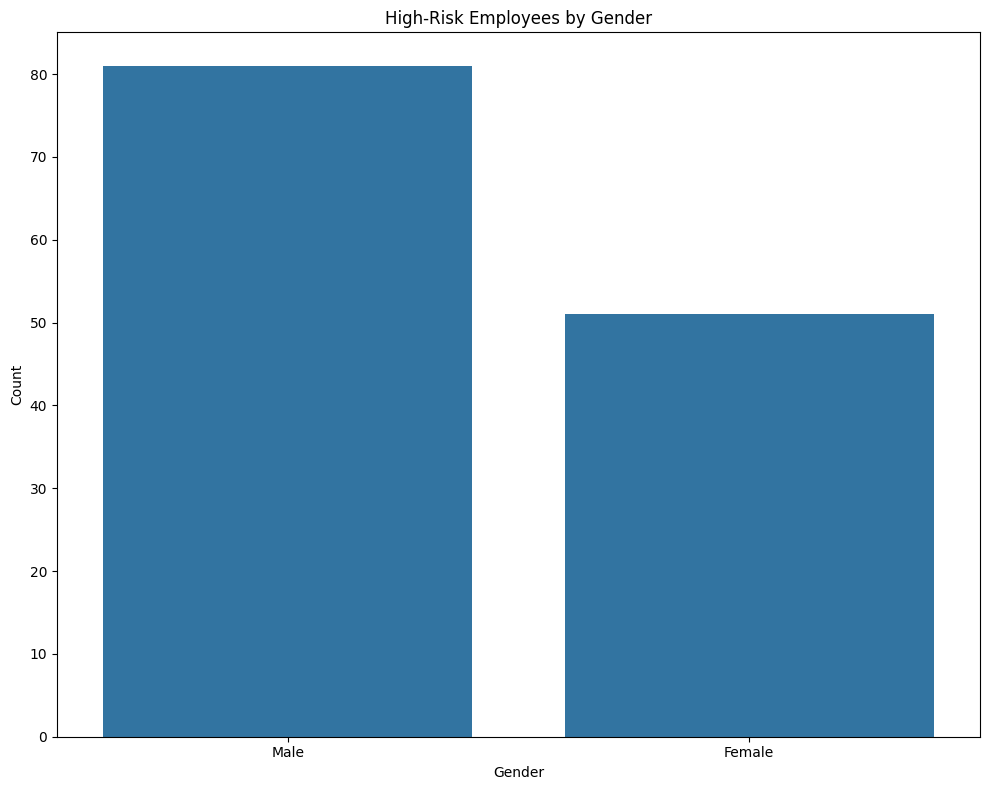

In [ ]:
# Visualizations for High-Risk Insights
plt.figure(figsize=(10, 8))
sns.countplot(x='Gender', data=high_risk)
plt.title('High-Risk Employees by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.tight_layout()
plt.show()

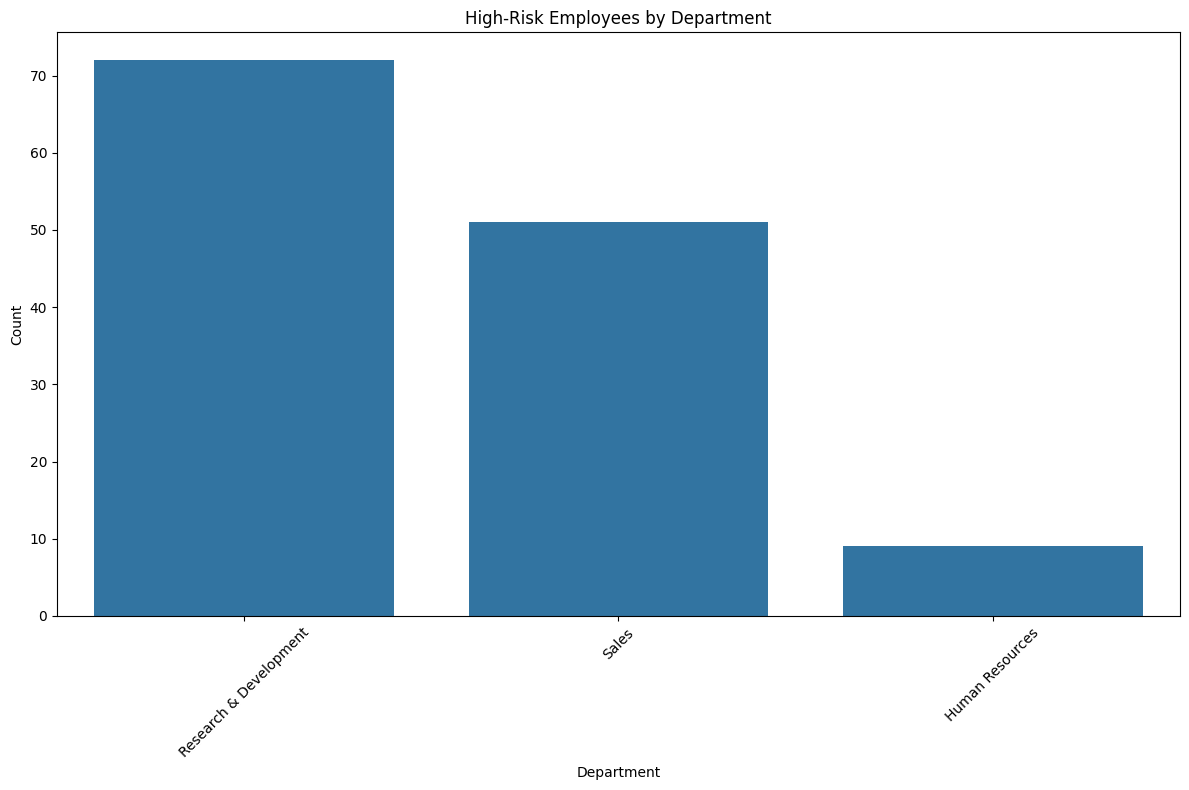

In [40]:
plt.figure(figsize=(12, 8))
sns.countplot(x='Department', data=high_risk)
plt.title('High-Risk Employees by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

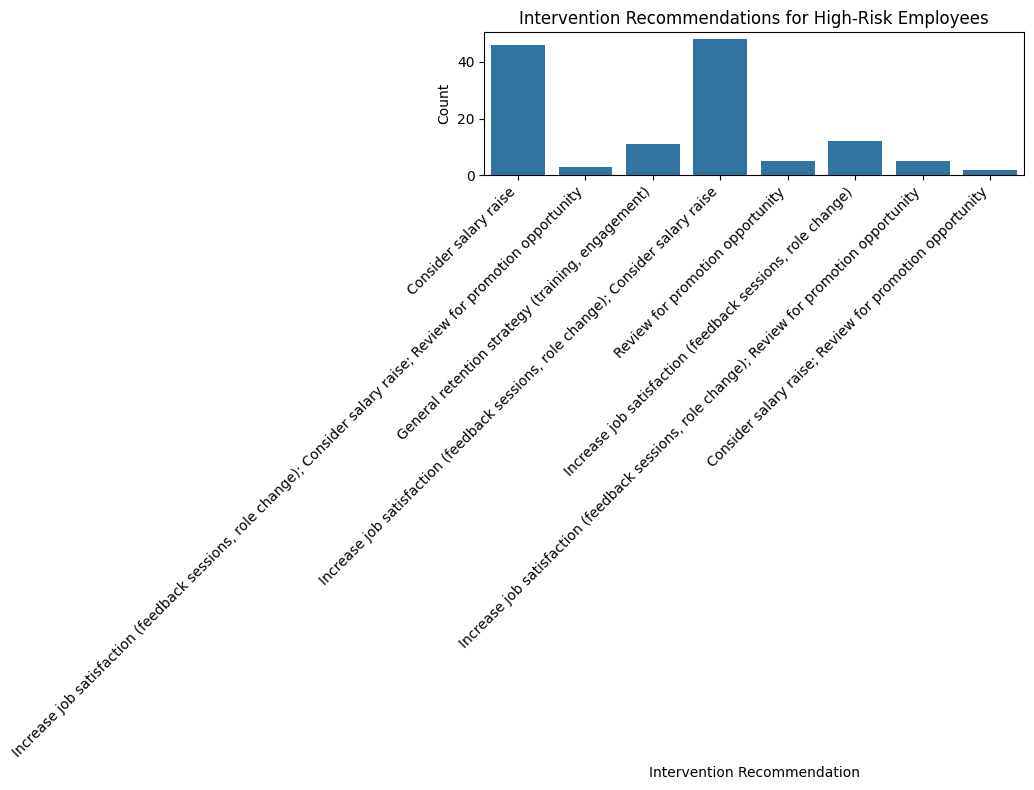

In [41]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Intervention_Recommendation', data=high_risk)
plt.title('Intervention Recommendations for High-Risk Employees')
plt.xlabel('Intervention Recommendation')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

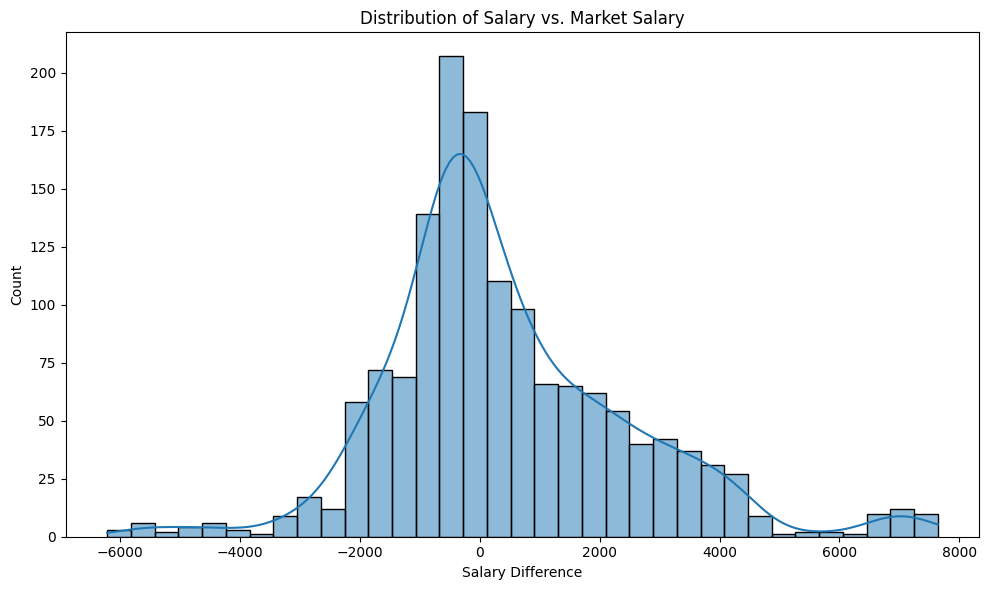

In [42]:
# Visualize Salary vs Market Salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary_vs_Market'], kde=True)
plt.title('Distribution of Salary vs. Market Salary')
plt.xlabel('Salary Difference')
plt.ylabel('Count')
plt.tight_layout()
plt.show()